# Hybrid Finance Lead Discovery Notebook — Bulgaria/EU with Telegram

This notebook uses a safer hybrid workflow:

**Search engine discovery → quick human review → Telegram direct channel retrieval → rule-based ranking → organized finance leads**

Supported discovery sources:
- Search engine results for Facebook, Instagram, TikTok, and Telegram public pages
- Optional direct Telegram retrieval from public/authorized channels using the official Telegram client API through Telethon
- Manual pasted search results

Target use cases:
- Forex/gold/stocks education interest
- General market interest
- Broker / introducing broker research
- Signal provider interest
- Copy trading, mirror trading, and managed account interest as high-risk categories

Important: this notebook does **not** provide financial advice. It does not infer private financial status, target vulnerable people, log into Facebook/Instagram/TikTok, bypass login walls, scrape private groups, or evade platform restrictions.

In [ ]:
!pip -q install pandas requests beautifulsoup4 lxml tqdm ipywidgets telethon nest_asyncio

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.6/773.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.1 MB/s eta 0:00:00


# 1. Configuration

In Colab Secrets, add whichever credentials you will use.

## Search engine discovery

Recommended no-card option:
- `SERPER_API_KEY`

Optional:
- `GOOGLE_API_KEY`
- `GOOGLE_CSE_ID`

Set `SEARCH_PROVIDER` to:
- `"serper"`
- `"google"`
- `"manual"`

## Telegram direct channel retrieval

For Telegram direct channel retrieval, add:

- `TELEGRAM_API_ID`
- `TELEGRAM_API_HASH`
- Optional: `TELEGRAM_PHONE`

Get `TELEGRAM_API_ID` and `TELEGRAM_API_HASH` from Telegram's developer app page.

The first time you run the Telegram cell, Telethon may ask you for the login code sent to your Telegram account. This creates a local session file in the Colab runtime.

Use Telegram retrieval only for public channels or channels/groups your Telegram account is allowed to access.

## Finance compliance boundary

The scoring is a commercial-fit and compliance-risk triage tool. It is not investment advice and should not be used to target people based on hardship, losses, debt, or other vulnerable signals.

In [ ]:
import os
import re
import time
from datetime import datetime
from typing import Dict, List, Tuple, Optional
from urllib.parse import urlparse

import pandas as pd
import requests
from bs4 import BeautifulSoup
from tqdm.auto import tqdm

try:
    from google.colab import userdata
except Exception:
    userdata = None

def get_secret(name: str, default: Optional[str] = None) -> Optional[str]:
    if userdata is not None:
        try:
            value = userdata.get(name)
            if value:
                return value
        except Exception:
            pass
    return os.getenv(name, default)

SERPER_API_KEY = get_secret("SERPER_API_KEY")
GOOGLE_API_KEY = get_secret("GOOGLE_API_KEY")
GOOGLE_CSE_ID = get_secret("GOOGLE_CSE_ID")

TELEGRAM_API_ID_RAW = get_secret("TELEGRAM_API_ID")
TELEGRAM_API_HASH = get_secret("TELEGRAM_API_HASH")
TELEGRAM_PHONE = get_secret("TELEGRAM_PHONE")

TELEGRAM_API_ID = int(TELEGRAM_API_ID_RAW) if TELEGRAM_API_ID_RAW else None

DOMAIN = "finance_bg_eu"
SEARCH_PROVIDER = "serper"  # "serper", "google", or "manual"
MAX_RESULTS_PER_QUERY = 10
DELAY_SECONDS_BETWEEN_QUERIES = 1.2

# Lightweight filters used for display/export.
# High-risk results remain in ranked_results, but are excluded from default final export unless enabled.
TARGET_REGION = "bulgaria_eu"
TARGET_LANGUAGES = ["english", "bulgarian"]
TARGET_PLATFORMS = ["facebook", "instagram", "tiktok", "telegram"]
TARGET_ASSETS = ["forex", "gold", "stocks"]
TARGET_USE_CASES = [
    "forex_educator",
    "signal_provider",
    "introducing_broker",
    "money_manager",
    "mirror_trading",
]
INCLUDE_HIGH_RISK_LEADS = False
MIN_COMMERCIAL_SCORE = 20

print("Serper API key loaded:", bool(SERPER_API_KEY))
print("Google API key loaded:", bool(GOOGLE_API_KEY))
print("Google CSE ID loaded:", bool(GOOGLE_CSE_ID))
print("Telegram API ID loaded:", bool(TELEGRAM_API_ID))
print("Telegram API hash loaded:", bool(TELEGRAM_API_HASH))
print("Selected search provider:", SEARCH_PROVIDER)
print("Domain:", DOMAIN)

Serper API key loaded: True
Google API key loaded: True
Google CSE ID loaded: True
Telegram API ID loaded: True
Telegram API hash loaded: True
Selected search provider: serper
Domain: finance_bg_eu


# 2. Query Templates

Finance-focused search queries for Bulgaria/EU trading education, market interest, broker research, signals, copy trading, and managed accounts.

The queries intentionally cover English and Bulgarian terms across Facebook, Instagram, TikTok, and public Telegram pages/channels.

In [ ]:
QUERIES = [
    # General trading interest
    'site:facebook.com "forex" "Bulgaria"',
    'site:facebook.com "gold trading" "Bulgaria"',
    'site:facebook.com "stocks" "Bulgaria"',
    'site:facebook.com "trading" "Bulgaria"',
    'site:instagram.com "forex Bulgaria"',
    'site:instagram.com "gold trading Bulgaria"',
    'site:tiktok.com "forex Bulgaria"',
    'site:tiktok.com "XAUUSD Bulgaria"',
    'site:t.me "forex Bulgaria"',
    'site:t.me "gold trading Bulgaria"',

    # Bulgarian-language trading terms
    'site:facebook.com "форекс" "България"',
    'site:facebook.com "търговия" "форекс"',
    'site:facebook.com "злато" "търговия"',
    'site:facebook.com "акции" "инвестиции"',
    'site:instagram.com "форекс" "България"',
    'site:tiktok.com "форекс" "България"',
    'site:t.me "форекс" "България"',
    'site:t.me "сигнали" "форекс"',

    # Signal provider demand
    'site:facebook.com "forex signals" "Bulgaria"',
    'site:facebook.com "XAUUSD signals"',
    'site:instagram.com "forex signals"',
    'site:tiktok.com "gold signals"',
    'site:t.me "forex signals"',
    'site:t.me "XAUUSD signals"',
    'site:t.me "сигнали" "форекс"',
    'site:t.me "сигнали" "злато"',

    # Forex educator demand
    'site:facebook.com "learn forex" "Bulgaria"',
    'site:facebook.com "forex course" "Bulgaria"',
    'site:instagram.com "learn trading"',
    'site:tiktok.com "how to trade forex"',
    'site:t.me "forex course"',
    'site:t.me "trading education"',
    'site:facebook.com "обучение" "форекс"',
    'site:t.me "обучение" "търговия"',

    # Introducing broker / broker research
    'site:facebook.com "best forex broker" "Bulgaria"',
    'site:facebook.com "regulated broker" "Bulgaria"',
    'site:t.me "forex broker Bulgaria"',
    'site:t.me "low spread broker"',
    'site:tiktok.com "best broker forex"',
    'site:facebook.com "брокер" "форекс"',
    'site:t.me "регулиран брокер"',

    # Mirror/copy trading
    'site:facebook.com "copy trading" "Bulgaria"',
    'site:t.me "copy trading"',
    'site:t.me "mirror trading"',
    'site:tiktok.com "copy trading forex"',
    'site:facebook.com "копиране на сделки"',
    'site:t.me "копиране на сделки"',

    # Money manager / managed account
    'site:facebook.com "managed forex account"',
    'site:t.me "account manager forex"',
    'site:t.me "PAMM"',
    'site:t.me "MAM account"',
    'site:tiktok.com "trade for me forex"',
    'site:facebook.com "управление на средства"',
]

pd.DataFrame({"query": QUERIES})

,query
0,"site:facebook.com ""forex"" ""Bulgaria"""
1,"site:facebook.com ""gold trading"" ""Bulgaria"""
2,"site:facebook.com ""stocks"" ""Bulgaria"""
3,"site:facebook.com ""trading"" ""Bulgaria"""
4,"site:instagram.com ""forex Bulgaria"""
5,"site:instagram.com ""gold trading Bulgaria"""
6,"site:tiktok.com ""forex Bulgaria"""
7,"site:tiktok.com ""XAUUSD Bulgaria"""
8,"site:t.me ""forex Bulgaria"""
9,"site:t.me ""gold trading Bulgaria"""


# 3. Discovery Helpers

In [ ]:
def detect_platform(url: str) -> str:
    url = (url or "").lower()
    if "facebook.com" in url or "fb.watch" in url:
        return "facebook"
    if "instagram.com" in url:
        return "instagram"
    if "tiktok.com" in url:
        return "tiktok"
    if "t.me/" in url or "telegram.me/" in url:
        return "telegram"
    return "other"


def make_result_row(
    source_query: str,
    title: str,
    snippet: str,
    link: str,
    display_link: str = "",
    provider: str = "",
    extra: Optional[Dict] = None,
) -> Dict:
    row = {
        "provider": provider,
        "source_query": source_query,
        "title": title or "",
        "snippet": snippet or "",
        "link": link or "",
        "display_link": display_link or "",
        "platform": detect_platform(link or ""),
        "manual_visible_text": "",
        "review_status": "not_reviewed",
        "notes": "",
    }
    if extra:
        row.update(extra)
    return row


def serper_search(query: str, num: int = 10) -> List[Dict]:
    if not SERPER_API_KEY:
        raise ValueError("Missing SERPER_API_KEY. Add it to Colab Secrets or use manual fallback.")

    url = "https://google.serper.dev/search"
    headers = {
        "X-API-KEY": SERPER_API_KEY,
        "Content-Type": "application/json",
    }
    payload = {"q": query, "num": num}

    response = requests.post(url, headers=headers, json=payload, timeout=30)
    data = response.json()

    if response.status_code >= 400:
        raise RuntimeError(f"Serper API error: {data}")

    rows = []
    for item in data.get("organic", []):
        rows.append(make_result_row(
            source_query=query,
            title=item.get("title", ""),
            snippet=item.get("snippet", ""),
            link=item.get("link", ""),
            display_link=item.get("source", ""),
            provider="serper",
        ))

    return rows


def google_custom_search(query: str, start: int = 1, num: int = 10) -> List[Dict]:
    if not GOOGLE_API_KEY or not GOOGLE_CSE_ID:
        raise ValueError("Missing GOOGLE_API_KEY or GOOGLE_CSE_ID.")

    url = "https://www.googleapis.com/customsearch/v1"
    params = {
        "key": GOOGLE_API_KEY,
        "cx": GOOGLE_CSE_ID,
        "q": query,
        "start": start,
        "num": num,
    }

    response = requests.get(url, params=params, timeout=30)
    payload = response.json()

    if response.status_code >= 400:
        raise RuntimeError(f"Google API error: {payload}")

    rows = []
    for item in payload.get("items", []):
        rows.append(make_result_row(
            source_query=query,
            title=item.get("title", ""),
            snippet=item.get("snippet", ""),
            link=item.get("link", ""),
            display_link=item.get("displayLink", ""),
            provider="google",
        ))

    return rows

# 4. Run Discovery

In [ ]:
all_rows = []

if SEARCH_PROVIDER == "manual":
    print("Manual mode selected. Skip to the manual fallback cell.")
else:
    for query in tqdm(QUERIES):
        try:
            if SEARCH_PROVIDER == "serper":
                rows = serper_search(query, num=MAX_RESULTS_PER_QUERY)
            elif SEARCH_PROVIDER == "google":
                rows = google_custom_search(query, num=MAX_RESULTS_PER_QUERY)
            else:
                raise ValueError("SEARCH_PROVIDER must be 'serper', 'google', or 'manual'.")

            all_rows.extend(rows)
            time.sleep(DELAY_SECONDS_BETWEEN_QUERIES)

        except Exception as exc:
            print(f"Query failed: {query}")
            print(exc)

raw_results = pd.DataFrame(all_rows)

if len(raw_results) > 0:
    raw_results = raw_results.drop_duplicates(subset=["link"]).reset_index(drop=True)

print("Total unique search-engine results:", len(raw_results))

if len(raw_results) > 0:
    display(raw_results[["provider", "platform", "title", "snippet", "link", "source_query"]].head(30))
else:
    print("No API results. Use the manual fallback section below, or add Telegram channels in the Telegram section.")

  0%|          | 0/53 [00:00<?, ?it/s]

Total unique search-engine results: 402


,provider,platform,title,snippet,link,source_query
0,serper,facebook,Forex in Bulgaria | Facebook,Forex in Bulgaria. Join group. About this grou...,https://www.facebook.com/groups/241988949335963/,"site:facebook.com ""forex"" ""Bulgaria"""
1,serper,facebook,Forex Job Opportunities in Bulgaria - Facebook,We're one of the biggest Forex companies in Bu...,https://www.facebook.com/groups/859851192762456/,"site:facebook.com ""forex"" ""Bulgaria"""
2,serper,facebook,Forex Trading Bulgaria | Facebook,"Forex Trading Bulgaria е социална група, която...",https://www.facebook.com/groups/471690543491729/,"site:facebook.com ""forex"" ""Bulgaria"""
3,serper,facebook,"Hey friends, I wanted to ask if anyone here kn...","Hey friends, I wanted to ask if anyone here kn...",https://www.facebook.com/groups/17522818483297...,"site:facebook.com ""forex"" ""Bulgaria"""
4,serper,facebook,If you are a pro in #Forex retention and your co,If you are a pro in #Forex retention ... CITY ...,https://www.facebook.com/61551889416629/posts/...,"site:facebook.com ""forex"" ""Bulgaria"""
5,serper,facebook,Forex Training Bulgaria | Asenovgrad - Facebook,"Forex Training Bulgaria, Asenovgrad. 587 likes...",https://www.facebook.com/ForexTrainingBulgaria...,"site:facebook.com ""forex"" ""Bulgaria"""
6,serper,facebook,Forex Forum Bulgaria (@ForexForumBulgaria) - F...,Forex Forum Bulgaria. 1550 likes · 3 talking a...,https://www.facebook.com/ForexForumBulgaria/,"site:facebook.com ""forex"" ""Bulgaria"""
7,serper,facebook,Forex in Bulgaria - Facebook,Log in · Forex in Bulgaria · Forex Signals Cyp...,https://m.facebook.com/groups/241988949335963/...,"site:facebook.com ""forex"" ""Bulgaria"""
8,serper,facebook,We Buy Back Bulgarian Lev Bulgaria has rec...,"From 1 February 2026 onward, only the euro wil...",https://www.facebook.com/HaysTravelNewtownards...,"site:facebook.com ""forex"" ""Bulgaria"""
9,serper,facebook,"Upfx Capital Markets, Ltd. | Sofia - Facebook","Upfx Capital Markets, Ltd., Sofia. 729 likes. ...",https://www.facebook.com/tradeforex/,"site:facebook.com ""forex"" ""Bulgaria"""


# 5. Manual Fallback

Use this when you search manually on Google/Serper/another search engine and paste results here.

You only need title, snippet, and link. The same finance ranking pipeline will still work.

In [ ]:
manual_rows = [
    # Example:
    # {
    #     "provider": "manual_search",
    #     "source_query": 'site:t.me "forex course" "Bulgaria"',
    #     "title": "Example title",
    #     "snippet": "Example snippet from search results...",
    #     "link": "https://t.me/example_channel/123",
    #     "display_link": "t.me/example_channel",
    #     "platform": "telegram",
    #     "manual_visible_text": "",
    #     "review_status": "not_reviewed",
    #     "notes": "",
    # },
]

manual_results = pd.DataFrame(manual_rows)

if "raw_results" not in globals() or raw_results.empty:
    raw_results = manual_results.copy()
elif not manual_results.empty:
    raw_results = pd.concat([raw_results, manual_results], ignore_index=True)
    raw_results = raw_results.drop_duplicates(subset=["link"]).reset_index(drop=True)

print("Current results:", len(raw_results))
display(raw_results.head())

Current results: 402


,provider,source_query,title,snippet,link,display_link,platform,manual_visible_text,review_status,notes
0,serper,"site:facebook.com ""forex"" ""Bulgaria""",Forex in Bulgaria | Facebook,Forex in Bulgaria. Join group. About this grou...,https://www.facebook.com/groups/241988949335963/,,facebook,,not_reviewed,
1,serper,"site:facebook.com ""forex"" ""Bulgaria""",Forex Job Opportunities in Bulgaria - Facebook,We're one of the biggest Forex companies in Bu...,https://www.facebook.com/groups/859851192762456/,,facebook,,not_reviewed,
2,serper,"site:facebook.com ""forex"" ""Bulgaria""",Forex Trading Bulgaria | Facebook,"Forex Trading Bulgaria е социална група, която...",https://www.facebook.com/groups/471690543491729/,,facebook,,not_reviewed,
3,serper,"site:facebook.com ""forex"" ""Bulgaria""","Hey friends, I wanted to ask if anyone here kn...","Hey friends, I wanted to ask if anyone here kn...",https://www.facebook.com/groups/17522818483297...,,facebook,,not_reviewed,
4,serper,"site:facebook.com ""forex"" ""Bulgaria""",If you are a pro in #Forex retention and your co,If you are a pro in #Forex retention ... CITY ...,https://www.facebook.com/61551889416629/posts/...,,facebook,,not_reviewed,


# 5B. Telegram Direct Channel Retrieval

Telegram has two practical API routes:

1. **Bot API**
   - Good for channels/groups where your bot is added and allowed to receive updates.
   - Not ideal for historical discovery across arbitrary public channels.

2. **Telegram client API / MTProto through Telethon**
   - Better for reading recent/history messages from public channels or private channels/groups your account is authorized to access.
   - Requires `TELEGRAM_API_ID` and `TELEGRAM_API_HASH`.
   - First run may ask for a phone login code.
   - Use slowly and with small limits.

Add public channel usernames or `t.me/...` links in `TELEGRAM_CHANNELS`.

In [ ]:
TELEGRAM_CHANNELS = [
    # Examples. Replace with real public Telegram channel usernames/links.
    # "@example_trading_channel",
    # "https://t.me/example_finance_channel",
]

TELEGRAM_SEARCH_TERMS = [
    # English general
    "forex Bulgaria",
    "gold trading Bulgaria",
    "stocks Bulgaria",
    "trading Bulgaria",
    "XAUUSD",
    "EURUSD",
    "NASDAQ trading",
    "TradingView",
    "MT4",
    "MT5",

    # Signal provider
    "forex signals",
    "gold signals",
    "XAUUSD signals",
    "telegram signals",
    "buy sell signal",
    "entry stop loss take profit",

    # Educator
    "learn forex",
    "forex course",
    "trading education",
    "technical analysis",
    "risk management",
    "beginner trader",

    # Broker / IB
    "best forex broker",
    "regulated broker",
    "low spread broker",
    "broker Bulgaria",
    "deposit withdrawal broker",

    # Copy / mirror / managed account
    "copy trading",
    "mirror trading",
    "PAMM",
    "MAM account",
    "managed account",
    "trade for me",

    # Bulgarian
    "форекс",
    "търговия",
    "злато",
    "акции",
    "инвестиции",
    "сигнали",
    "обучение форекс",
    "брокер форекс",
    "регулиран брокер",
    "копиране на сделки",
    "управление на средства",
]

TELEGRAM_RECENT_LIMIT_PER_CHANNEL = 100
TELEGRAM_SEARCH_LIMIT_PER_TERM = 30

pd.DataFrame({
    "telegram_channels": TELEGRAM_CHANNELS or ["Add channel usernames here"],
})

,telegram_channels
0,Add channel usernames here


In [ ]:
import asyncio
import nest_asyncio
nest_asyncio.apply()

from telethon import TelegramClient
from telethon.errors import (
    FloodWaitError,
    ChannelPrivateError,
    UsernameInvalidError,
    UsernameNotOccupiedError,
)

TELEGRAM_SESSION_NAME = "telegram_lead_discovery_session"


def clean_telegram_channel_ref(channel_ref: str) -> str:
    channel_ref = str(channel_ref or "").strip()
    channel_ref = channel_ref.replace("https://t.me/s/", "")
    channel_ref = channel_ref.replace("http://t.me/s/", "")
    channel_ref = channel_ref.replace("https://t.me/", "")
    channel_ref = channel_ref.replace("http://t.me/", "")
    channel_ref = channel_ref.replace("telegram.me/", "")
    channel_ref = channel_ref.split("?")[0].strip("/")
    return channel_ref.lstrip("@")


def telegram_message_link(channel_username: str, message_id: int) -> str:
    if not channel_username:
        return ""
    return f"https://t.me/{channel_username}/{message_id}"


async def fetch_telegram_channel_rows(
    channels: List[str],
    search_terms: List[str],
    recent_limit_per_channel: int = 100,
    search_limit_per_term: int = 30,
) -> pd.DataFrame:
    if not channels:
        print("No Telegram channels configured. Add public channel usernames to TELEGRAM_CHANNELS.")
        return pd.DataFrame()

    if not TELEGRAM_API_ID or not TELEGRAM_API_HASH:
        raise ValueError("Missing TELEGRAM_API_ID or TELEGRAM_API_HASH in Colab Secrets.")

    client = TelegramClient(
        TELEGRAM_SESSION_NAME,
        TELEGRAM_API_ID,
        TELEGRAM_API_HASH,
    )

    rows = []

    await client.start(phone=TELEGRAM_PHONE)

    for original_ref in channels:
        channel_ref = clean_telegram_channel_ref(original_ref)

        try:
            entity = await client.get_entity(channel_ref)
            channel_title = getattr(entity, "title", channel_ref)
            channel_username = getattr(entity, "username", channel_ref)

            # 1) Recent posts, useful when Telegram search misses keyword variants.
            async for msg in client.iter_messages(entity, limit=recent_limit_per_channel):
                text = msg.message or ""
                if not text.strip():
                    continue

                rows.append(make_result_row(
                    provider="telegram_api_recent",
                    source_query=f"telegram_recent:{channel_ref}",
                    title=channel_title,
                    snippet=text[:1000],
                    link=telegram_message_link(channel_username, msg.id),
                    display_link=f"t.me/{channel_username}" if channel_username else "telegram",
                    extra={
                        "platform": "telegram",
                        "created_time": msg.date.isoformat() if msg.date else "",
                        "telegram_channel": channel_ref,
                        "telegram_message_id": msg.id,
                    },
                ))

            # 2) Server-side search within the channel.
            for term in search_terms:
                async for msg in client.iter_messages(
                    entity,
                    search=term,
                    limit=search_limit_per_term,
                ):
                    text = msg.message or ""
                    if not text.strip():
                        continue

                    rows.append(make_result_row(
                        provider="telegram_api_search",
                        source_query=f"telegram_search:{channel_ref}:{term}",
                        title=channel_title,
                        snippet=text[:1000],
                        link=telegram_message_link(channel_username, msg.id),
                        display_link=f"t.me/{channel_username}" if channel_username else "telegram",
                        extra={
                            "platform": "telegram",
                            "created_time": msg.date.isoformat() if msg.date else "",
                            "telegram_channel": channel_ref,
                            "telegram_message_id": msg.id,
                        },
                    ))

            time.sleep(0.8)

        except FloodWaitError as exc:
            print(f"Telegram flood wait for {channel_ref}: wait {exc.seconds} seconds. Skipping for now.")
        except (ChannelPrivateError, UsernameInvalidError, UsernameNotOccupiedError) as exc:
            print(f"Cannot access Telegram channel {original_ref}: {type(exc).__name__}")
        except Exception as exc:
            print(f"Telegram retrieval failed for {original_ref}: {type(exc).__name__}: {exc}")

    await client.disconnect()

    df = pd.DataFrame(rows)
    if len(df) > 0:
        df = df.drop_duplicates(subset=["link", "snippet"]).reset_index(drop=True)

    return df


telegram_results = await fetch_telegram_channel_rows(
    TELEGRAM_CHANNELS,
    TELEGRAM_SEARCH_TERMS,
    recent_limit_per_channel=TELEGRAM_RECENT_LIMIT_PER_CHANNEL,
    search_limit_per_term=TELEGRAM_SEARCH_LIMIT_PER_TERM,
)

print("Telegram rows:", len(telegram_results))
if len(telegram_results) > 0:
    display(telegram_results[[
        "platform", "title", "snippet", "link", "source_query", "created_time"
    ]].head(30))

    if "raw_results" not in globals() or raw_results.empty:
        raw_results = telegram_results.copy()
    else:
        raw_results = pd.concat([raw_results, telegram_results], ignore_index=True)
        raw_results = raw_results.drop_duplicates(subset=["link", "snippet"]).reset_index(drop=True)

print("Total combined rows:", len(raw_results) if "raw_results" in globals() else 0)

No Telegram channels configured. Add public channel usernames to TELEGRAM_CHANNELS.
Telegram rows: 0
Total combined rows: 402


# 6. Text Normalization and Finance Keyword Dictionaries

This section defines English and Bulgarian finance terms for lightweight, explainable scoring.

The notebook preserves evidence from source text. It should not infer private financial status or provide financial advice.

In [ ]:
def normalize_text(text: str) -> str:
    """Normalize text for lightweight keyword matching."""
    text = str(text or "")
    text = text.lower()
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


REGION_TERMS = [
    "bulgaria", "bulgarian", "sofia", "varna", "plovdiv", "europe", "eu",
    "българия", "български", "софия", "варна", "пловдив", "европа", "ес",
]

ASSET_TERMS = {
    "forex": [
        "forex", "fx", "eurusd", "gbpusd", "usdjpy", "forex market",
        "форекс", "валутна търговия",
    ],
    "gold": [
        "gold", "xauusd", "gold trading", "злато", "търговия със злато",
    ],
    "stocks": [
        "stocks", "stock market", "shares", "equities", "nasdaq", "s&p 500", "sp500",
        "акции", "фондов пазар", "инвестиции",
    ],
    "indices": [
        "nas100", "us30", "dow", "dax", "indices", "индекси",
    ],
    # Kept optional so crypto does not dominate a stocks/gold/forex-focused MVP.
    "crypto_optional": [
        "crypto", "bitcoin", "btc", "ethereum", "eth", "крипто",
    ],
}

SIGNAL_PROVIDER_TERMS = [
    "signals", "forex signals", "gold signals", "xauusd signals",
    "buy signal", "sell signal", "entry", "stop loss", "take profit", "tp", "sl",
    "premium signals", "free signals", "telegram signals",
    "сигнали", "форекс сигнали", "сигнали за злато",
]

FOREX_EDUCATOR_TERMS = [
    "learn forex", "forex course", "trading course", "trading education",
    "beginner trader", "how to trade", "technical analysis", "price action",
    "risk management", "candlestick", "backtesting", "tradingview", "mt4", "mt5",
    "обучение", "обучение форекс", "курс форекс", "технически анализ",
]

IB_BROKER_TERMS = [
    "broker", "forex broker", "best broker", "regulated broker", "low spread",
    "ecn broker", "deposit", "withdrawal", "leverage", "account type",
    "rebate", "ib", "introducing broker", "affiliate broker",
    "брокер", "форекс брокер", "регулиран брокер", "лост", "депозит", "теглене",
]

MONEY_MANAGER_TERMS = [
    "managed account", "account manager", "manage my account", "trade for me",
    "portfolio manager", "profit share", "pamm", "mam account",
    "управление на средства", "управление на акаунт",
]

MIRROR_TRADING_TERMS = [
    "copy trading", "mirror trading", "social trading", "copy trader",
    "auto copy", "follow trader", "copy trades",
    "копиране на сделки", "копи трейдинг",
]

# These terms increase compliance risk instead of commercial score.
VULNERABLE_RISK_TERMS = [
    "lost money", "lost everything", "in debt", "need money fast",
    "guaranteed profit", "guaranteed income", "recover losses",
    "passive income guaranteed", "no risk",
    "загубих пари", "дълг", "бързи пари", "гарантирана печалба", "без риск",
]

HIGH_RISK_FINANCE_TERMS = [
    "leverage", "high leverage", "cfds", "cfd", "binary options",
    "managed account", "trade for me", "copy trading", "mirror trading",
    "profit share", "pamm", "mam",
    "лост", "договори за разлика", "управление на средства", "копиране на сделки",
]

NEGATIVE_FINANCE_TERMS = [
    "job", "hiring", "vacancy", "casino", "betting", "sports betting",
    "scam warning", "exposed scam",
    "работа", "обява за работа", "казино", "залагания",
]

STRONG_INTENT_TERMS = [
    "learn forex", "forex course", "trading education", "beginner trader",
    "best broker", "regulated broker", "forex signals", "gold signals",
    "copy trading", "managed account", "trade for me",
    "обучение форекс", "регулиран брокер", "форекс сигнали",
]

USE_CASE_WEIGHTS = {
    "forex_educator": 25,
    "signal_provider": 18,
    "introducing_broker": 15,
    "mirror_trading": 8,
    "money_manager": 5,
}

# 7. Finance Lead Scoring

The scoring is lightweight and rule-based.

Important compliance design:
- `commercial_fit_score` measures source-text relevance to the finance use cases.
- `compliance_risk` is separate and should not be treated as a positive score.
- High-risk categories are detected but excluded from the default export unless `INCLUDE_HIGH_RISK_LEADS = True`.

In [ ]:
def contains_any(text: str, terms: List[str]) -> List[str]:
    t = normalize_text(text)
    hits = []
    for term in terms:
        term_norm = normalize_text(term)
        if term_norm and term_norm in t:
            hits.append(term)
    return hits


def match_term_groups(text: str, term_groups: Dict[str, List[str]]) -> Dict[str, List[str]]:
    matches = {}
    for group_name, terms in term_groups.items():
        hits = contains_any(text, terms)
        if hits:
            matches[group_name] = hits
    return matches


def classify_finance_use_cases(text: str) -> Dict[str, List[str]]:
    use_cases = {
        "signal_provider": contains_any(text, SIGNAL_PROVIDER_TERMS),
        "forex_educator": contains_any(text, FOREX_EDUCATOR_TERMS),
        "introducing_broker": contains_any(text, IB_BROKER_TERMS),
        "money_manager": contains_any(text, MONEY_MANAGER_TERMS),
        "mirror_trading": contains_any(text, MIRROR_TRADING_TERMS),
    }
    return {name: hits for name, hits in use_cases.items() if hits}


def classify_asset_interest(text: str) -> Dict[str, List[str]]:
    return match_term_groups(text, ASSET_TERMS)


def classify_finance_risk(text: str, use_cases: Optional[Dict[str, List[str]]] = None) -> Tuple[str, List[str]]:
    use_cases = use_cases or {}

    vulnerable_hits = contains_any(text, VULNERABLE_RISK_TERMS)
    high_risk_hits = contains_any(text, HIGH_RISK_FINANCE_TERMS)
    risk_reasons = []

    if vulnerable_hits:
        risk_reasons.extend([f"vulnerable-risk term: {hit}" for hit in vulnerable_hits])

    if high_risk_hits:
        risk_reasons.extend([f"high-risk finance term: {hit}" for hit in high_risk_hits])

    # Copy/mirror trading and money management are high-risk by default.
    if "money_manager" in use_cases:
        risk_reasons.append("money manager / managed account use case detected")
    if "mirror_trading" in use_cases:
        risk_reasons.append("copy/mirror trading use case detected")

    if vulnerable_hits or "money_manager" in use_cases or "mirror_trading" in use_cases:
        return "high", risk_reasons

    # Signal and broker research can be commercially relevant, but require compliance review.
    if "signal_provider" in use_cases:
        risk_reasons.append("signal-related language detected")
    if "introducing_broker" in use_cases:
        risk_reasons.append("broker / introducing broker language detected")

    if risk_reasons:
        return "medium", risk_reasons

    return "low", []


def choose_primary_use_case(use_cases: Dict[str, List[str]]) -> str:
    if not use_cases:
        return ""
    return max(use_cases.keys(), key=lambda name: USE_CASE_WEIGHTS.get(name, 0))


def to_csv_list(value) -> str:
    if isinstance(value, dict):
        return ", ".join(value.keys())
    if isinstance(value, (list, tuple, set)):
        return ", ".join(str(v) for v in value)
    return str(value or "")


def recommend_action(primary_use_case: str, compliance_risk: str, risk_reasons: List[str]) -> str:
    reasons_text = normalize_text(" ".join(risk_reasons))

    if "vulnerable-risk term" in reasons_text:
        return "not_suitable_for_outreach"

    if compliance_risk == "high":
        if primary_use_case == "money_manager":
            return "licensed_provider_only_or_exclude"
        if primary_use_case == "mirror_trading":
            return "high_risk_review_required"
        return "high_compliance_risk_review_required"

    if primary_use_case == "forex_educator" and compliance_risk == "low":
        return "education_outreach"

    if primary_use_case == "signal_provider":
        return "review_before_signal_outreach"

    if primary_use_case == "introducing_broker":
        return "broker_compliance_review_required"

    if compliance_risk == "medium":
        return "compliance_review_required"

    return "general_market_interest_review"


def score_finance_result(row: pd.Series) -> Dict:
    combined_text = " ".join([
        str(row.get("title", "")),
        str(row.get("snippet", "")),
        str(row.get("manual_visible_text", "")),
    ])

    score = 0
    reasons = []
    matched_terms = []

    region_hits = contains_any(combined_text, REGION_TERMS)
    asset_matches = classify_asset_interest(combined_text)
    use_cases = classify_finance_use_cases(combined_text)
    primary_use_case = choose_primary_use_case(use_cases)
    negative_hits = contains_any(combined_text, NEGATIVE_FINANCE_TERMS)
    strong_intent_hits = contains_any(combined_text, STRONG_INTENT_TERMS)

    # Asset match: relevant asset interest, capped to avoid over-weighting repeated keywords.
    if asset_matches:
        matched_assets = [asset for asset in asset_matches.keys() if asset != "crypto_optional"]
        asset_score = min(10, 4 * len(matched_assets))
        score += asset_score
        reasons.append(f"asset match: {', '.join(matched_assets or asset_matches.keys())}")
        for hits in asset_matches.values():
            matched_terms.extend(hits[:5])

    # Use-case match: education is intentionally prioritized for a safer MVP.
    if use_cases:
        use_case_score = min(35, sum(USE_CASE_WEIGHTS.get(name, 0) for name in use_cases))
        score += use_case_score
        reasons.append(f"use case match: {', '.join(use_cases.keys())}")
        for hits in use_cases.values():
            matched_terms.extend(hits[:5])

    # Region/language match: Bulgaria/EU context.
    if region_hits:
        score += min(10, 3 * len(region_hits))
        reasons.append(f"region match: {', '.join(region_hits[:5])}")
        matched_terms.extend(region_hits[:5])

    # Strong intent phrases make the result more actionable, but still evidence-based.
    if strong_intent_hits:
        score += min(20, 4 * len(strong_intent_hits))
        reasons.append(f"strong intent phrase: {', '.join(strong_intent_hits[:5])}")
        matched_terms.extend(strong_intent_hits[:5])

    platform = str(row.get("platform", "")).lower()
    provider = str(row.get("provider", "")).lower()
    source_query = str(row.get("source_query", "")).lower()

    if platform in ["facebook", "instagram", "tiktok", "telegram"]:
        score += 3
        reasons.append(f"social platform: {platform}")

    if platform == "telegram" or provider.startswith("telegram") or source_query.startswith("telegram_"):
        score += 3
        reasons.append("telegram source")

    if provider in ["serper", "google"] or source_query:
        score += 5
        reasons.append("search/discovery source available")

    if negative_hits:
        penalty = min(20, 5 * len(negative_hits))
        score -= penalty
        reasons.append(f"negative/noise terms: {', '.join(negative_hits[:5])}")
        matched_terms.extend(negative_hits[:5])

    compliance_risk, risk_reasons = classify_finance_risk(combined_text, use_cases)
    recommended_action = recommend_action(primary_use_case, compliance_risk, risk_reasons)

    if not reasons:
        reasons.append("weak or irrelevant match")

    return {
        "lead_score": score,
        "commercial_fit_score": score,
        "finance_use_cases": to_csv_list(use_cases),
        "primary_use_case": primary_use_case,
        "asset_interest": to_csv_list(asset_matches),
        "region_hits": to_csv_list(region_hits),
        "matched_terms": to_csv_list(sorted(set(matched_terms))),
        "compliance_risk": compliance_risk,
        "risk_reasons": "; ".join(risk_reasons),
        "score_reasons": "; ".join(reasons),
        "recommended_action": recommended_action,
    }


def apply_scoring(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    scored = df.copy()
    score_rows = scored.apply(score_finance_result, axis=1).apply(pd.Series)
    scored = pd.concat([scored.reset_index(drop=True), score_rows.reset_index(drop=True)], axis=1)

    scored["lead_quality"] = pd.cut(
        scored["commercial_fit_score"],
        bins=[-999, 20, 45, 70, 999],
        labels=["low", "medium", "high", "very_high"],
    )

    scored = scored.sort_values(
        by=["commercial_fit_score", "compliance_risk", "platform"],
        ascending=[False, True, True],
    ).reset_index(drop=True)

    return scored


def row_has_any_target(value: str, targets: List[str]) -> bool:
    if not targets:
        return True
    value_set = {v.strip() for v in str(value or "").split(",") if v.strip()}
    return bool(value_set.intersection(set(targets)))


def filter_ranked_results(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    filtered = df.copy()

    if TARGET_PLATFORMS:
        filtered = filtered[filtered["platform"].isin(TARGET_PLATFORMS)]

    if not INCLUDE_HIGH_RISK_LEADS:
        filtered = filtered[filtered["compliance_risk"] != "high"]

    filtered = filtered[filtered["commercial_fit_score"] >= MIN_COMMERCIAL_SCORE]

    if TARGET_USE_CASES:
        filtered = filtered[
            filtered["finance_use_cases"].apply(lambda x: row_has_any_target(x, TARGET_USE_CASES))
        ]

    if TARGET_ASSETS:
        filtered = filtered[
            filtered["asset_interest"].apply(lambda x: row_has_any_target(x, TARGET_ASSETS))
        ]

    return filtered.reset_index(drop=True)


ranked_results = apply_scoring(raw_results)
filtered_results = filter_ranked_results(ranked_results)

if len(ranked_results) > 0:
    display(ranked_results[[
        "lead_score", "lead_quality", "commercial_fit_score", "compliance_risk",
        "primary_use_case", "finance_use_cases", "asset_interest", "recommended_action",
        "platform", "title", "snippet", "score_reasons", "risk_reasons", "link"
    ]].head(30))

    print("Default filtered results for review/export:", len(filtered_results))
else:
    print("No results to score yet.")

,lead_score,lead_quality,commercial_fit_score,compliance_risk,primary_use_case,finance_use_cases,asset_interest,recommended_action,platform,title,snippet,score_reasons,risk_reasons,link
0,58,high,58,high,signal_provider,"signal_provider, introducing_broker, mirror_tr...",forex,high_compliance_risk_review_required,telegram,Duplikium Trade Copier | Forex Signals/Prop Fi...,You can now filter master orders to copy by se...,asset match: forex; use case match: signal_pro...,high-risk finance term: copy trading; copy/mir...,https://t.me/s/duplikium?before=37
1,58,high,58,medium,forex_educator,"signal_provider, forex_educator",forex,compliance_review_required,telegram,The Ace Trading (Free Forex Signals),Trading Education & Technical Analysis This ch...,asset match: forex; use case match: signal_pro...,signal-related language detected,https://t.me/TheAcetrading
2,58,high,58,medium,forex_educator,"signal_provider, forex_educator",gold,compliance_review_required,telegram,Trading Education – Telegram,Trading Education. If you are looking for the ...,asset match: gold; use case match: signal_prov...,signal-related language detected,https://t.me/s/tradingview_algo/183
3,57,high,57,medium,forex_educator,"signal_provider, forex_educator, introducing_b...","forex, gold, stocks",compliance_review_required,tiktok,Forex Broker Name for Deriv in Tradingview | T...,HFM THE BEST BROKER #forex #xauusd #hfm #forex...,"asset match: forex, gold, stocks; use case mat...",signal-related language detected; broker / int...,https://www.tiktok.com/discover/forex-broker-n...
4,55,high,55,medium,forex_educator,"signal_provider, forex_educator","forex, gold",compliance_review_required,tiktok,Forex Trading Lifestyle & Gold Signals - TikTok,"1715 Likes, 57 Comments. TikTok video from GOL...","asset match: forex, gold; use case match: sign...",signal-related language detected,https://www.tiktok.com/@gold_mt4/video/7626735...
5,55,high,55,medium,signal_provider,"signal_provider, introducing_broker","forex, gold, stocks",review_before_signal_outreach,tiktok,Top 10 Broker Forex Trading for Metatrader 4 |...,HFM THE BEST BROKER #forex #xauusd #hfm #forex...,"asset match: forex, gold, stocks; use case mat...",signal-related language detected; broker / int...,https://www.tiktok.com/discover/top-10-broker-...
6,55,high,55,medium,signal_provider,"signal_provider, introducing_broker","forex, gold, stocks",review_before_signal_outreach,tiktok,Best Broker for Meta 5 - TikTok,HFM THE BEST BROKER #forex #xauusd #hfm #forex...,"asset match: forex, gold, stocks; use case mat...",signal-related language detected; broker / int...,https://www.tiktok.com/discover/best-broker-fo...
7,55,high,55,medium,signal_provider,"signal_provider, introducing_broker","forex, gold, stocks",review_before_signal_outreach,tiktok,Which Broker Is Best Between Just Markets and ...,HFM THE BEST BROKER #forex #xauusd #hfm #forex...,"asset match: forex, gold, stocks; use case mat...",signal-related language detected; broker / int...,https://www.tiktok.com/discover/which-broker-i...
8,54,high,54,medium,forex_educator,"forex_educator, introducing_broker",forex,compliance_review_required,telegram,Telegram: View @forexcourse1234,Forex Course Free. 22 924 subscribers. Premium...,asset match: forex; use case match: forex_educ...,broker / introducing broker language detected,https://t.me/forexcourse1234/20409
9,54,high,54,medium,forex_educator,"signal_provider, forex_educator",forex,compliance_review_required,telegram,HABBY fOREX ACAdEMy – Telegram,signals available 2_6 signals a day with minim...,asset match: forex; use case match: signal_pro...,signal-related language detected,https://t.me/s/habbyforex/573


Default filtered results for review/export: 179


In [ ]:
ranked_results['primary_use_case'].value_counts()

,count
primary_use_case,
,117
forex_educator,88
signal_provider,86
introducing_broker,58
mirror_trading,33
money_manager,20


In [ ]:
ranked_results['platform'].value_counts()

,count
platform,
facebook,185
telegram,115
tiktok,62
instagram,40


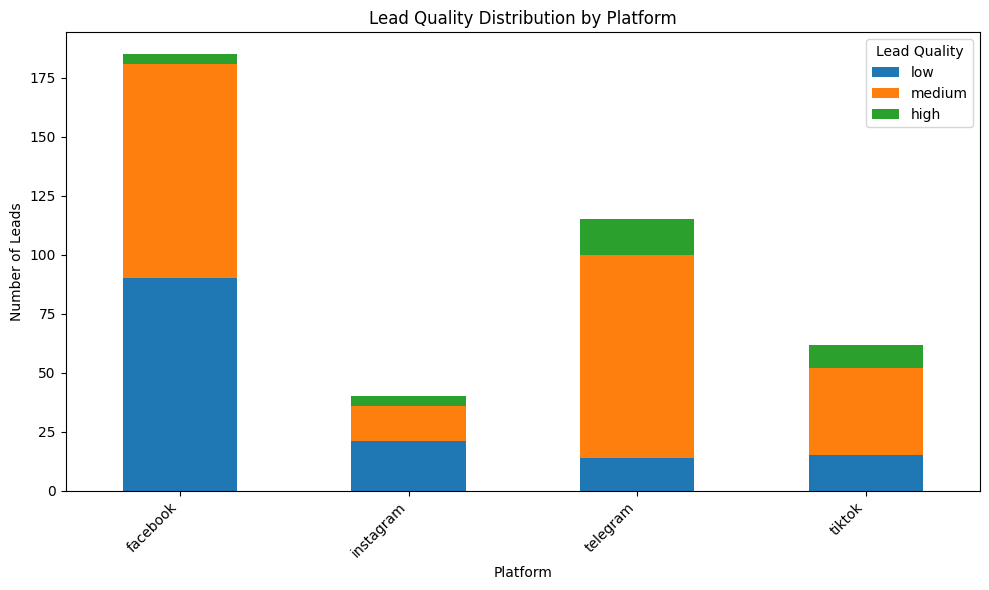

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a crosstab of platform and lead_quality
platform_lead_quality = pd.crosstab(ranked_results['platform'], ranked_results['lead_quality'])

# Plotting the stacked bar chart
platform_lead_quality.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Lead Quality Distribution by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Lead Quality')
plt.tight_layout()
plt.show()

In [ ]:
high_quality_telegram_leads = ranked_results[
    (ranked_results['platform'] == 'telegram') &
    (ranked_results['lead_quality'] == 'high')
]

display(high_quality_telegram_leads[['link', 'primary_use_case']])

,link,primary_use_case
0,https://t.me/s/duplikium?before=37,signal_provider
1,https://t.me/TheAcetrading,forex_educator
2,https://t.me/s/tradingview_algo/183,forex_educator
8,https://t.me/forexcourse1234/20409,forex_educator
9,https://t.me/s/habbyforex/573,forex_educator
10,https://t.me/s/trade_ed?before=337,forex_educator
13,https://t.me/s/successfulforexsignalsfree?befo...,forex_educator
14,https://t.me/s/wealthgkforex?before=1244,forex_educator
15,https://t.me/+m4-f-e3_r81jMTA0,signal_provider
21,https://t.me/joinchat/10ztP8GZHDozZmE0,forex_educator


In [ ]:
import pandas as pd
from datetime import datetime
from google.colab import files

if 'high_quality_telegram_leads' in globals() and not high_quality_telegram_leads.empty:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_path = f"high_quality_telegram_leads_{timestamp}.csv"
    high_quality_telegram_leads.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Saved high-quality Telegram leads to: {output_path}")
    print(f"Exported rows: {len(high_quality_telegram_leads)}")
    try:
        files.download(output_path)
    except Exception:
        print("If not in Colab, download the CSV from the current working directory.")
else:
    print("No high-quality Telegram leads found to download.")

Saved high-quality Telegram leads to: high_quality_telegram_leads_20260501_120657.csv
Exported rows: 15


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 8. Review Queue

The default review queue excludes high-risk leads unless `INCLUDE_HIGH_RISK_LEADS = True`.

High-risk rows are still preserved in `ranked_results`; they are just not prioritized for default outreach/export.

In [ ]:
review_cols = [
    "lead_score",
    "lead_quality",
    "commercial_fit_score",
    "compliance_risk",
    "primary_use_case",
    "finance_use_cases",
    "asset_interest",
    "recommended_action",
    "platform",
    "title",
    "snippet",
    "score_reasons",
    "risk_reasons",
    "manual_visible_text",
    "review_status",
    "notes",
    "link",
]

if len(ranked_results) > 0:
    review_queue = filtered_results[review_cols].copy()
    display(review_queue.head(30))
else:
    print("No review queue yet.")

,lead_score,lead_quality,commercial_fit_score,compliance_risk,primary_use_case,finance_use_cases,asset_interest,recommended_action,platform,title,snippet,score_reasons,risk_reasons,manual_visible_text,review_status,notes,link
0,58,high,58,medium,forex_educator,"signal_provider, forex_educator",forex,compliance_review_required,telegram,The Ace Trading (Free Forex Signals),Trading Education & Technical Analysis This ch...,asset match: forex; use case match: signal_pro...,signal-related language detected,,not_reviewed,,https://t.me/TheAcetrading
1,58,high,58,medium,forex_educator,"signal_provider, forex_educator",gold,compliance_review_required,telegram,Trading Education – Telegram,Trading Education. If you are looking for the ...,asset match: gold; use case match: signal_prov...,signal-related language detected,,not_reviewed,,https://t.me/s/tradingview_algo/183
2,57,high,57,medium,forex_educator,"signal_provider, forex_educator, introducing_b...","forex, gold, stocks",compliance_review_required,tiktok,Forex Broker Name for Deriv in Tradingview | T...,HFM THE BEST BROKER #forex #xauusd #hfm #forex...,"asset match: forex, gold, stocks; use case mat...",signal-related language detected; broker / int...,,not_reviewed,,https://www.tiktok.com/discover/forex-broker-n...
3,55,high,55,medium,forex_educator,"signal_provider, forex_educator","forex, gold",compliance_review_required,tiktok,Forex Trading Lifestyle & Gold Signals - TikTok,"1715 Likes, 57 Comments. TikTok video from GOL...","asset match: forex, gold; use case match: sign...",signal-related language detected,,not_reviewed,,https://www.tiktok.com/@gold_mt4/video/7626735...
4,55,high,55,medium,signal_provider,"signal_provider, introducing_broker","forex, gold, stocks",review_before_signal_outreach,tiktok,Top 10 Broker Forex Trading for Metatrader 4 |...,HFM THE BEST BROKER #forex #xauusd #hfm #forex...,"asset match: forex, gold, stocks; use case mat...",signal-related language detected; broker / int...,,not_reviewed,,https://www.tiktok.com/discover/top-10-broker-...
5,55,high,55,medium,signal_provider,"signal_provider, introducing_broker","forex, gold, stocks",review_before_signal_outreach,tiktok,Best Broker for Meta 5 - TikTok,HFM THE BEST BROKER #forex #xauusd #hfm #forex...,"asset match: forex, gold, stocks; use case mat...",signal-related language detected; broker / int...,,not_reviewed,,https://www.tiktok.com/discover/best-broker-fo...
6,55,high,55,medium,signal_provider,"signal_provider, introducing_broker","forex, gold, stocks",review_before_signal_outreach,tiktok,Which Broker Is Best Between Just Markets and ...,HFM THE BEST BROKER #forex #xauusd #hfm #forex...,"asset match: forex, gold, stocks; use case mat...",signal-related language detected; broker / int...,,not_reviewed,,https://www.tiktok.com/discover/which-broker-i...
7,54,high,54,medium,forex_educator,"forex_educator, introducing_broker",forex,compliance_review_required,telegram,Telegram: View @forexcourse1234,Forex Course Free. 22 924 subscribers. Premium...,asset match: forex; use case match: forex_educ...,broker / introducing broker language detected,,not_reviewed,,https://t.me/forexcourse1234/20409
8,54,high,54,medium,forex_educator,"signal_provider, forex_educator",forex,compliance_review_required,telegram,HABBY fOREX ACAdEMy – Telegram,signals available 2_6 signals a day with minim...,asset match: forex; use case match: signal_pro...,signal-related language detected,,not_reviewed,,https://t.me/s/habbyforex/573
9,53,high,53,medium,forex_educator,"signal_provider, forex_educator","forex, crypto_optional",compliance_review_required,instagram,#forex #bulgaria #forexstrategy #trading #sofi...,#forex #bulgaria #forexstrategy #trading #sofi...,asset match: forex; use case match: signal_pro...,signal-related language detected,,not_reviewed,,https://www.instagram.com/p/DOsfzisDbY5/


# 9. Optional Public Visible Text Fetcher

This only requests public HTML. It does not log in, execute JavaScript, or bypass walls.

For Facebook/Instagram/TikTok, expect many pages to return login/sign-up walls.

In [ ]:
def fetch_public_visible_text(url: str, timeout: int = 20) -> str:
    headers = {
        "User-Agent": "Mozilla/5.0 LeadResearchNotebook/1.0",
        "Accept-Language": "en-US,en;q=0.9",
    }

    try:
        response = requests.get(url, headers=headers, timeout=timeout)
        if response.status_code >= 400:
            return f"[FETCH_FAILED status={response.status_code}]"

        html = response.text or ""
        lower_html = html.lower()

        login_wall_markers = ["log in to facebook", "login", "sign up", "create an account"]
        if any(marker in lower_html for marker in login_wall_markers):
            return "[LOGIN_OR_SIGNUP_WALL_DETECTED]"

        soup = BeautifulSoup(html, "lxml")
        for tag in soup(["script", "style", "noscript", "svg", "canvas"]):
            tag.decompose()

        text = soup.get_text(separator=" ")
        text = re.sub(r"\s+", " ", text).strip()
        return text[:5000]

    except Exception as exc:
        return f"[FETCH_ERROR {type(exc).__name__}: {exc}]"

# 10. Final Lead Table and Export

By default, the export uses `filtered_results`, which excludes high-risk leads unless `INCLUDE_HIGH_RISK_LEADS = True`.

The full unfiltered scoring output remains available in `ranked_results`.

In [ ]:
def extract_possible_handle(url: str) -> str:
    try:
        parsed = urlparse(url)
        host = parsed.netloc.lower().replace("www.", "")
        parts = [p for p in parsed.path.split("/") if p]

        if "instagram.com" in host and parts:
            return parts[0]
        if "tiktok.com" in host and parts:
            return parts[0]
        if "t.me" in host or "telegram.me" in host:
            if parts and parts[0] == "s" and len(parts) > 1:
                return parts[1]
            if parts:
                return parts[0]
        if "facebook.com" in host and parts:
            if parts[0] in ["groups", "posts", "watch", "reel", "story.php"]:
                return parts[0]
            return parts[0]
        return ""
    except Exception:
        return ""


def ensure_columns(df: pd.DataFrame, columns: List[str], default: str = "") -> pd.DataFrame:
    safe_df = df.copy()
    for col in columns:
        if col not in safe_df.columns:
            safe_df[col] = default
    return safe_df


if len(ranked_results) > 0:
    export_source = filtered_results.copy()
    export_source["possible_handle_or_page"] = export_source["link"].apply(extract_possible_handle)
    export_source["action_status"] = "research_more"

    final_cols = [
        "lead_score",
        "lead_quality",
        "commercial_fit_score",
        "compliance_risk",
        "recommended_action",
        "primary_use_case",
        "finance_use_cases",
        "asset_interest",
        "region_hits",
        "action_status",
        "review_status",
        "platform",
        "possible_handle_or_page",
        "title",
        "snippet",
        "manual_visible_text",
        "matched_terms",
        "score_reasons",
        "risk_reasons",
        "link",
        "source_query",
        "notes",
    ]

    export_source = ensure_columns(export_source, final_cols)
    final_leads = export_source[final_cols].sort_values(
        by="commercial_fit_score",
        ascending=False,
    ).reset_index(drop=True)

    display(final_leads.head(50))

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_path = f"finance_bg_eu_leads_{timestamp}.csv"
    final_leads.to_csv(output_path, index=False, encoding="utf-8-sig")
    print("Saved:", output_path)
    print("Exported rows:", len(final_leads))
    print("Full unfiltered scored rows remain in ranked_results:", len(ranked_results))

    try:
        from google.colab import files
        # Uncomment to trigger download in Colab:
        # files.download(output_path)
    except Exception:
        print("If not in Colab, download the CSV from the current working directory.")
else:
    final_leads = pd.DataFrame()
    print("No final leads yet.")

,lead_score,lead_quality,commercial_fit_score,compliance_risk,recommended_action,primary_use_case,finance_use_cases,asset_interest,region_hits,action_status,...,possible_handle_or_page,title,snippet,manual_visible_text,matched_terms,score_reasons,risk_reasons,link,source_query,notes
0,58,high,58,medium,compliance_review_required,forex_educator,"signal_provider, forex_educator",forex,,research_more,...,TheAcetrading,The Ace Trading (Free Forex Signals),Trading Education & Technical Analysis This ch...,,"forex, forex signals, signals, technical analy...",asset match: forex; use case match: signal_pro...,signal-related language detected,https://t.me/TheAcetrading,"site:t.me ""trading education""",
1,58,high,58,medium,compliance_review_required,forex_educator,"signal_provider, forex_educator",gold,,research_more,...,tradingview_algo,Trading Education – Telegram,Trading Education. If you are looking for the ...,,"gold, gold signals, signals, tp, trading educa...",asset match: gold; use case match: signal_prov...,signal-related language detected,https://t.me/s/tradingview_algo/183,"site:t.me ""trading education""",
2,57,high,57,medium,compliance_review_required,forex_educator,"signal_provider, forex_educator, introducing_b...","forex, gold, stocks",,research_more,...,discover,Forex Broker Name for Deriv in Tradingview | T...,HFM THE BEST BROKER #forex #xauusd #hfm #forex...,,"best broker, broker, forex, forex broker, shar...","asset match: forex, gold, stocks; use case mat...",signal-related language detected; broker / int...,https://www.tiktok.com/discover/forex-broker-n...,"site:tiktok.com ""best broker forex""",
3,55,high,55,medium,compliance_review_required,forex_educator,"signal_provider, forex_educator","forex, gold",,research_more,...,@gold_mt4,Forex Trading Lifestyle & Gold Signals - TikTok,"1715 Likes, 57 Comments. TikTok video from GOL...",,"forex, gold, gold signals, mt4, signals","asset match: forex, gold; use case match: sign...",signal-related language detected,https://www.tiktok.com/@gold_mt4/video/7626735...,"site:tiktok.com ""gold signals""",
4,55,high,55,medium,review_before_signal_outreach,signal_provider,"signal_provider, introducing_broker","forex, gold, stocks",,research_more,...,discover,Top 10 Broker Forex Trading for Metatrader 4 |...,HFM THE BEST BROKER #forex #xauusd #hfm #forex...,,"best broker, broker, forex, shares, sl, xauusd","asset match: forex, gold, stocks; use case mat...",signal-related language detected; broker / int...,https://www.tiktok.com/discover/top-10-broker-...,"site:tiktok.com ""best broker forex""",
5,55,high,55,medium,review_before_signal_outreach,signal_provider,"signal_provider, introducing_broker","forex, gold, stocks",,research_more,...,discover,Best Broker for Meta 5 - TikTok,HFM THE BEST BROKER #forex #xauusd #hfm #forex...,,"best broker, broker, forex, shares, sl, xauusd","asset match: forex, gold, stocks; use case mat...",signal-related language detected; broker / int...,https://www.tiktok.com/discover/best-broker-fo...,"site:tiktok.com ""best broker forex""",
6,55,high,55,medium,review_before_signal_outreach,signal_provider,"signal_provider, introducing_broker","forex, gold, stocks",,research_more,...,discover,Which Broker Is Best Between Just Markets and ...,HFM THE BEST BROKER #forex #xauusd #hfm #forex...,,"best broker, broker, forex, shares, sl, xauusd","asset match: forex, gold, stocks; use case mat...",signal-related language detected; broker / int...,https://www.tiktok.com/discover/which-broker-i...,"site:tiktok.com ""best broker forex""",
7,54,high,54,medium,compliance_review_required,forex_educator,"forex_educator, introducing_broker",forex,,research_more,...,forexcourse1234,Telegram: View @forexcourse1234,Forex Course Free. 22 924 subscribers. Premium...,,"forex, forex course, ib, trading course",asset match: forex; use case match: forex_educ...,broker / introducing broker language detected,https://t.me/forexcourse1234/20409,"site:t.me ""forex course""",
8,54,high,5

Saved: finance_bg_eu_leads_20260501_115900.csv
Exported rows: 179
Full unfiltered scored rows remain in ranked_results: 402


# Telegram Notes

- Use `site:t.me ...` queries for broad public discovery through search engines.
- Use Telethon direct retrieval only for known public channels or channels/groups your account can access.
- Bot API is better for monitoring your own channel after adding the bot as admin; it is not the best tool for historical public channel search.
- Keep limits small while prototyping and avoid collecting unnecessary personal data.
- For finance use cases, review compliance-risk labels before any outreach.